# HUẤN LUYỆN TRÊN DỮ LIỆU GỐC

## MÔ HÌNH HUẤN LUYỆN

In [ ]:
import time
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### One-hot coding

In [ ]:
def convert_labels(y, C):
    Y = sparse.coo_matrix((np.ones_like(y),
    (y, np.arange(len(y)))), shape = (C, len(y))).toarray()
    return Y


### Huấn luyện

In [ ]:

# Tính xác suất của từng lớp
def softmax_stable(Z):
    e_Z = np.exp(Z - np.max(Z, axis = 0, keepdims = True))
    A = e_Z / e_Z.sum(axis = 0)
    return A

def softmax(Z):
    e_Z = np.exp(Z)
    A = e_Z / e_Z.sum(axis = 0)
    return A

# Tính cross entropy có trọng số
def cost(X, Y, W, class_weights=None):
    A = softmax(W.T.dot(X))
    if class_weights is not None:
        weighted_Y = Y * class_weights.reshape(-1, 1)
        return -np.sum(weighted_Y * np.log(A )) / X.shape[1]
    return -np.sum(Y * np.log(A)) / X.shape[1]

# Huấn luyện mô hình có sử dụng class weight
def softmax_regression(X, y, W_init, eta, class_weights=None, tol = 1e-4, max_count = 50000):
    y_arr = np.array(y)

    W = [W_init]
    C = W_init.shape[1]
    Y = convert_labels(y_arr, C)
    N = X.shape[1]
    d = X.shape[0]
    losses = []
    count = 0
    check_w_after = 100

    while count < max_count:
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = Y[:, i].reshape(C, 1)
            ai = softmax(np.dot(W[-1].T, xi))

            # Cập nhật W có nhân thêm trọng số
            if class_weights is not None:
                # Lấy nhãn lớp của mẫu thứ i
                label_i = int(y_arr[i])
                weight = class_weights[label_i]
                W_new = W[-1] + eta * weight * xi.dot((yi - ai).T)
            else:
                W_new = W[-1] + eta * xi.dot((yi - ai).T)

            count += 1
            if count % check_w_after == 0:
                current_loss = cost(X, Y, W_new, class_weights)
                losses.append(current_loss)
                if np.linalg.norm(W_new - W[-check_w_after]) < tol:
                    W.append(W_new)
                    return W, losses
            W.append(W_new)
    return W, losses

# Tìm y dự đoán
def pred(W, X):
    A = softmax_stable(W.T.dot(X))
    return np.argmax(A, axis = 0)


In [ ]:


def prepare_data(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    N_train = X_train_scaled.shape[0]
    N_test = X_test_scaled.shape[0]
    X_train_scaled = np.concatenate((np.ones((1, N_train)), X_train_scaled.T), axis=0)
    X_test_scaled = np.concatenate((np.ones((1, N_test)), X_test_scaled.T), axis=0)

    return X_train_scaled, X_test_scaled

def evaluate_model(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return acc, prec, rec, f1

##ĐỌC DỮ LIỆU


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_excel("https://docs.google.com/spreadsheets/d/18_CZfdaiREcmWERh-zLfmrvDcw9vlkXw/export?format=xlsx")
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395.0,610.291,208.178117,173.888747,1.197191,0.573352,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,5
1,28734.0,638.018,200.524796,182.734419,1.097356,0.573352,29172.0,191.272750,0.783968,0.984986,0.887034,0.941333,0.006979,0.003564,0.867076,0.998430,5
2,29380.0,624.110,212.826130,175.931143,1.209713,0.573352,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,5
3,30008.0,645.884,210.557999,182.516516,1.153638,0.573352,30724.0,195.467062,0.782681,0.979168,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,5
4,30140.0,620.134,201.847882,190.279279,1.060798,0.573352,30417.0,195.896503,0.773098,0.990893,0.984877,0.941333,0.006697,0.003665,0.867076,0.999166,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13538,42097.0,759.696,288.721612,185.944705,1.552728,0.765002,42508.0,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,3
13539,42101.0,757.499,281.576392,190.713136,1.476439,0.735702,42494.0,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,3
13540,42139.0,759.321,281.539928,191.187979,1.472582,0.734065,42569.0,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,3
13541,42147.0,763.779,283.382636,190.275731,1.489326,0.741055,42667.0,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,3


In [ ]:
import requests
import json
import numpy as np

file_id = "1nkCYzynPA4fardpNeZf16Moz_0UenYEp"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

response = requests.get(url)
response.raise_for_status()  # báo lỗi nếu link sai

cw_dict = response.json()

class_weights_arr = np.array(
    [cw_dict[str(i)] for i in range(len(cw_dict))]
)


In [ ]:
y = df['Class']
X = df.drop('Class', axis=1)
C = len(np.unique(y))

## CHIA TẬP DỮ LIỆU

In [ ]:
np.random.seed(42)


### Chia tỷ lệ 4 : 1

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
X_train_scaled, X_test_scaled = prepare_data(X_train, X_test)


In [ ]:
d = X_train_scaled.shape[0]
W_init = np.random.randn(d, C)
eta = .05
start_train = time.time()
# Ví dụ thay đổi dòng này:
W, losses = softmax_regression(X_train_scaled, y_train, W_init, eta, class_weights=class_weights_arr)
end_train = time.time()
train_time = end_train - start_train
y_pred_train = pred(W[-1], X_train_scaled)


start_test = time.time()
y_pred_test = pred(W[-1], X_test_scaled)
end_test = time.time()
predict_time = end_test - start_test




print("Thời gian huấn luyện trên dữ liệu gốc tỷ lệ (4 : 1) : ", train_time)
print("Thời gian dự đoán trên dữ liệu gốc tỷ lệ (4 : 1) : ", predict_time)

Thời gian huấn luyện trên dữ liệu gốc tỷ lệ (4 : 1) :  11.150929689407349
Thời gian dự đoán trên dữ liệu gốc tỷ lệ (4 : 1) :  0.003161907196044922


#### Biểu diễn hàm mất mát

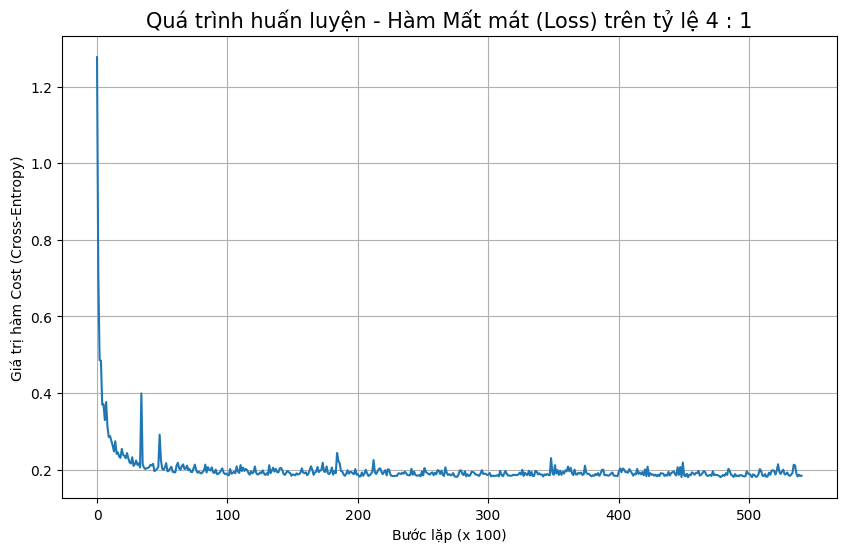

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Quá trình huấn luyện - Hàm Mất mát (Loss) trên tỷ lệ 4 : 1', fontsize=15)
plt.xlabel('Bước lặp (x 100)')
plt.ylabel('Giá trị hàm Cost (Cross-Entropy)')
plt.grid(True)
plt.show()

#### Dự đoán trên tập Train và Test




In [ ]:
train_scores = evaluate_model(y_train, y_pred_train)
test_scores = evaluate_model(y_test, y_pred_test)

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
print("Đánh giá mô hình:")
for i, m in enumerate(metrics):
    print(f"{m:10s}: Train = {train_scores[i]*100:.2f}% | Test = {test_scores[i]*100:.2f}%")


Đánh giá mô hình:
Accuracy  : Train = 91.63% | Test = 90.88%
Precision : Train = 91.98% | Test = 91.34%
Recall    : Train = 91.63% | Test = 90.88%
F1-score  : Train = 91.68% | Test = 90.94%


In [ ]:
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(8,5))
bar_train = plt.bar(x - width/2, train_scores, width, label='Train', color='#87CEEB')
bar_test = plt.bar(x + width/2, test_scores, width, label='Test', color='#4682B4')
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height*100:.2f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9)

add_labels(bar_train)
add_labels(bar_test)
plt.xticks(x, metrics)
plt.ylabel('Tỉ lệ chính xác')
plt.title('So sánh độ chính xác giữa tập Train và Test')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Trực quan hóa và đánh giá tương quan giữa phần dư

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực tế')
plt.title('Ma trận nhầm lẫn - Tỷ lệ 4:1')
plt.show()

### Chia tỷ lệ 6 : 4


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)


In [ ]:
X_train_scaled, X_test_scaled = prepare_data(X_train, X_test)


In [ ]:
d = X_train_scaled.shape[0]
W_init = np.random.randn(d, C)
eta = .05
start_train = time.time()
# Ví dụ thay đổi dòng này:
W, losses = softmax_regression(X_train_scaled, y_train, W_init, eta, class_weights=class_weights_arr)
end_train = time.time()
train_time = end_train - start_train
y_pred_train = pred(W[-1], X_train_scaled)


start_test = time.time()
y_pred_test = pred(W[-1], X_test_scaled)
end_test = time.time()
predict_time = end_test - start_test




print("Thời gian huấn luyện trên dữ liệu gốc tỷ lệ (6 : 4) : ", train_time)
print("Thời gian dự đoán trên dữ liệu gốc tỷ lệ (6 : 4) : ", predict_time)

#### Biểu diễn hàm mất mát

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Quá trình huấn luyện - Hàm Mất mát (Loss) trên tỷ lệ 6 : 4', fontsize=15)
plt.xlabel('Bước lặp (x 100)')
plt.ylabel('Giá trị hàm Cost (Cross-Entropy)')
plt.grid(True)
plt.show()

#### Dự đoán trên tập Train và Test

In [ ]:
train_scores = evaluate_model(y_train, y_pred_train)
test_scores = evaluate_model(y_test, y_pred_test)

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
print("Đánh giá mô hình:")
for i, m in enumerate(metrics):
    print(f"{m:10s}: Train = {train_scores[i]*100:.2f}% | Test = {test_scores[i]*100:.2f}%")


In [ ]:
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(8,5))
bar_train = plt.bar(x - width/2, train_scores, width, label='Train', color='#87CEEB')
bar_test = plt.bar(x + width/2, test_scores, width, label='Test', color='#4682B4')
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height*100:.2f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9)

add_labels(bar_train)
add_labels(bar_test)
plt.xticks(x, metrics)
plt.ylabel('Tỉ lệ chính xác')
plt.title('So sánh độ chính xác giữa tập Train và Test')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Trực quan hóa và đánh giá tương quan giữa phần dư

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực tế')
plt.title('Ma trận nhầm lẫn - Tỷ lệ 6:4')
plt.show()

### Chia tỷ lệ 7 : 3




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


In [ ]:
X_train_scaled, X_test_scaled = prepare_data(X_train, X_test)


In [ ]:
d = X_train_scaled.shape[0]
W_init = np.random.randn(d, C)
eta = .05
start_train = time.time()
# Ví dụ thay đổi dòng này:
W, losses = softmax_regression(X_train_scaled, y_train, W_init, eta, class_weights=class_weights_arr)
end_train = time.time()
train_time = end_train - start_train
y_pred_train = pred(W[-1], X_train_scaled)


start_test = time.time()
y_pred_test = pred(W[-1], X_test_scaled)
end_test = time.time()
predict_time = end_test - start_test




print("Thời gian huấn luyện trên dữ liệu gốc tỷ lệ (7 : 3) : ", train_time)
print("Thời gian dự đoán trên dữ liệu gốc tỷ lệ (7 : 3) : ", predict_time)

#### Biểu diễn hàm mất mát

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Quá trình huấn luyện - Hàm Mất mát (Loss) trên tỷ lệ 7 : 3', fontsize=15)
plt.xlabel('Bước lặp (x 100)')
plt.ylabel('Giá trị hàm Cost (Cross-Entropy)')
plt.grid(True)
plt.show()

#### Dự đoán trên tập Train và Test

In [ ]:
train_scores = evaluate_model(y_train, y_pred_train)
test_scores = evaluate_model(y_test, y_pred_test)

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
print("Đánh giá mô hình:")
for i, m in enumerate(metrics):
    print(f"{m:10s}: Train = {train_scores[i]*100:.2f}% | Test = {test_scores[i]*100:.2f}%")


In [ ]:
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(8,5))
bar_train = plt.bar(x - width/2, train_scores, width, label='Train', color='#87CEEB')
bar_test = plt.bar(x + width/2, test_scores, width, label='Test', color='#4682B4')
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height*100:.2f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9)

add_labels(bar_train)
add_labels(bar_test)
plt.xticks(x, metrics)
plt.ylabel('Tỉ lệ chính xác')
plt.title('So sánh độ chính xác giữa tập Train và Test')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Trực quan hóa và đánh giá tương quan giữa phần dư

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực tế')
plt.title('Ma trận nhầm lẫn - Tỷ lệ 7:3')
plt.show()

# HUẤN LUYỆN TRÊN DỮ LIỆU ĐÃ GIẢM CHIỀU

## THEO PHƯƠNG PHÁP PCA

### ĐỌC DỮ LIỆU

In [ ]:
df =  pd.read_excel("https://docs.google.com/spreadsheets/d/1S6LDJZWdgnj44FAuzrHlPmSlpinH-Unm/export?format=xlsx")
df

In [ ]:
y = df['Class']
X = df.drop('Class', axis=1)
C = len(np.unique(y))

### CHIA TẬP DỮ LIỆU

In [ ]:
np.random.seed(42)


#### Chia tỷ lệ 4 : 1

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
X_train_scaled, X_test_scaled = prepare_data(X_train, X_test)


In [ ]:
d = X_train_scaled.shape[0]
W_init = np.random.randn(d, C)
eta = .05
start_train = time.time()
# Ví dụ thay đổi dòng này:
W, losses = softmax_regression(X_train_scaled, y_train, W_init, eta, class_weights=class_weights_arr)
end_train = time.time()
train_time = end_train - start_train
y_pred_train = pred(W[-1], X_train_scaled)


start_test = time.time()
y_pred_test = pred(W[-1], X_test_scaled)
end_test = time.time()
predict_time = end_test - start_test



print("Thời gian huấn luyện trên dữ liệu PCA tỷ lệ (4 : 1) : ", train_time)
print("Thời gian dự đoán trên dữ liệu PCA tỷ lệ (4 : 1) : ", predict_time)

##### Biểu diễn hàm mất mát

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Quá trình huấn luyện - Hàm Mất mát (Loss) trên tỷ lệ 4 : 1', fontsize=15)
plt.xlabel('Bước lặp (x 100)')
plt.ylabel('Giá trị hàm Cost (Cross-Entropy)')
plt.grid(True)
plt.show()

##### Dự đoán trên tập Train và Test

In [ ]:
train_scores = evaluate_model(y_train, y_pred_train)
test_scores = evaluate_model(y_test, y_pred_test)

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
print("Đánh giá mô hình:")
for i, m in enumerate(metrics):
    print(f"{m:10s}: Train = {train_scores[i]*100:.2f}% | Test = {test_scores[i]*100:.2f}%")


In [ ]:
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(8,5))
bar_train = plt.bar(x - width/2, train_scores, width, label='Train', color='#87CEEB')
bar_test = plt.bar(x + width/2, test_scores, width, label='Test', color='#4682B4')
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height*100:.2f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9)

add_labels(bar_train)
add_labels(bar_test)
plt.xticks(x, metrics)
plt.ylabel('Tỉ lệ chính xác')
plt.title('So sánh độ chính xác giữa tập Train và Test')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Trực quan hóa và đánh giá tương quan giữa phần dư

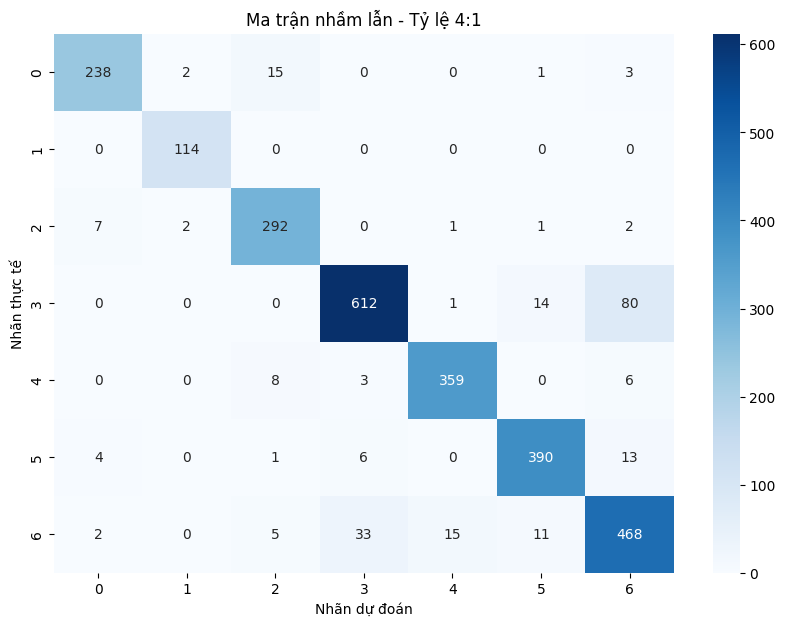

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực tế')
plt.title('Ma trận nhầm lẫn - Tỷ lệ 4:1')
plt.show()

#### Chia tỷ lệ 6 : 4

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)


In [ ]:
X_train_scaled, X_test_scaled = prepare_data(X_train, X_test)


In [ ]:
d = X_train_scaled.shape[0]
W_init = np.random.randn(d, C)
eta = .05
start_train = time.time()
# Ví dụ thay đổi dòng này:
W, losses = softmax_regression(X_train_scaled, y_train, W_init, eta, class_weights=class_weights_arr)
end_train = time.time()
train_time = end_train - start_train
y_pred_train = pred(W[-1], X_train_scaled)


start_test = time.time()
y_pred_test = pred(W[-1], X_test_scaled)
end_test = time.time()
predict_time = end_test - start_test




print("Thời gian huấn luyện trên dữ liệu PCA tỷ lệ (6 : 4) : ", train_time)
print("Thời gian dự đoán trên dữ liệu PCA tỷ lệ (6 : 4) : ", predict_time)

Thời gian huấn luyện trên dữ liệu PCA tỷ lệ (6 : 4) :  1.8896968364715576
Thời gian dự đoán trên dữ liệu PCA tỷ lệ (6 : 4) :  0.0011115074157714844


###### Biểu diễn hàm mất mát

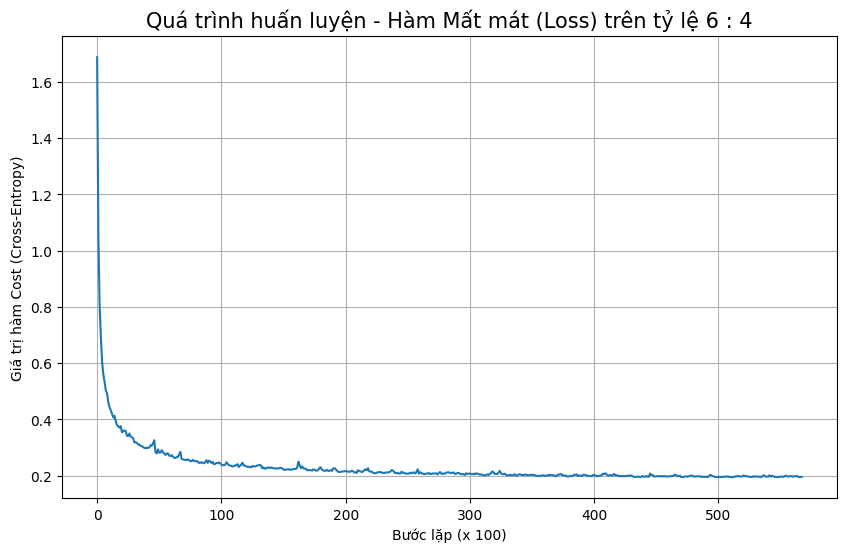

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Quá trình huấn luyện - Hàm Mất mát (Loss) trên tỷ lệ 6 : 4', fontsize=15)
plt.xlabel('Bước lặp (x 100)')
plt.ylabel('Giá trị hàm Cost (Cross-Entropy)')
plt.grid(True)
plt.show()

##### Dự đoán trên tập Train và Test

In [ ]:
train_scores = evaluate_model(y_train, y_pred_train)
test_scores = evaluate_model(y_test, y_pred_test)

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
print("Đánh giá mô hình:")
for i, m in enumerate(metrics):
    print(f"{m:10s}: Train = {train_scores[i]*100:.2f}% | Test = {test_scores[i]*100:.2f}%")


Đánh giá mô hình:
Accuracy  : Train = 91.98% | Test = 91.69%
Precision : Train = 92.03% | Test = 91.77%
Recall    : Train = 91.98% | Test = 91.69%
F1-score  : Train = 91.98% | Test = 91.71%


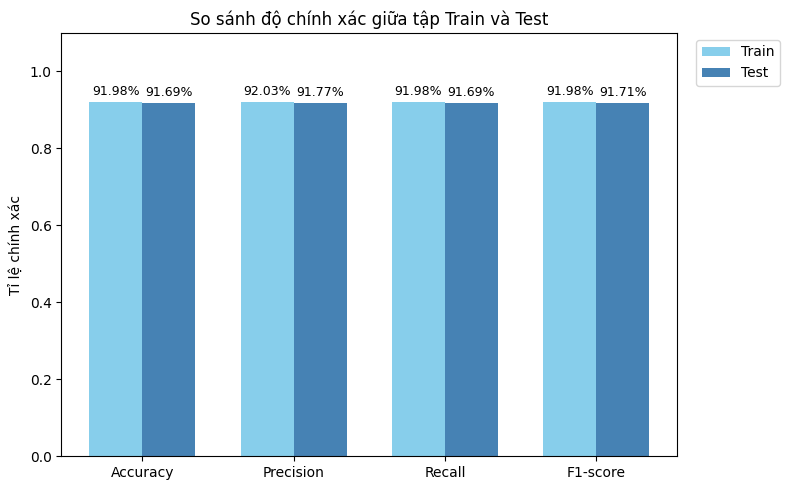

In [ ]:
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(8,5))
bar_train = plt.bar(x - width/2, train_scores, width, label='Train', color='#87CEEB')
bar_test = plt.bar(x + width/2, test_scores, width, label='Test', color='#4682B4')
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height*100:.2f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9)

add_labels(bar_train)
add_labels(bar_test)
plt.xticks(x, metrics)
plt.ylabel('Tỉ lệ chính xác')
plt.title('So sánh độ chính xác giữa tập Train và Test')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Trực quan hóa và đánh giá tương quan giữa phần dư

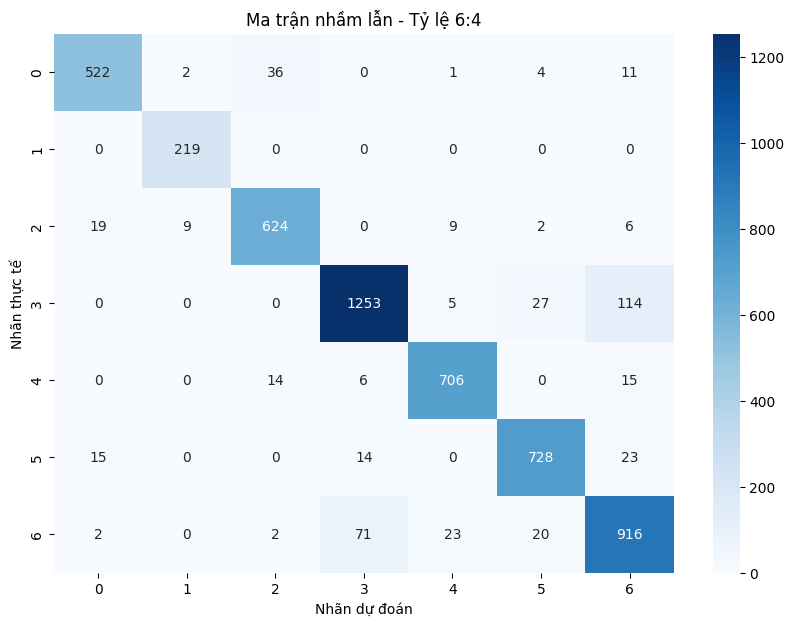

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực tế')
plt.title('Ma trận nhầm lẫn - Tỷ lệ 6:4')
plt.show()


#### Chia tỷ lệ 7 : 3

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


In [ ]:
X_train_scaled, X_test_scaled = prepare_data(X_train, X_test)


In [ ]:
d = X_train_scaled.shape[0]
W_init = np.random.randn(d, C)
eta = .05
start_train = time.time()
# Ví dụ thay đổi dòng này:
W, losses = softmax_regression(X_train_scaled, y_train, W_init, eta, class_weights=class_weights_arr)
end_train = time.time()
train_time = end_train - start_train
y_pred_train = pred(W[-1], X_train_scaled)


start_test = time.time()
y_pred_test = pred(W[-1], X_test_scaled)
end_test = time.time()
predict_time = end_test - start_test



print("Thời gian huấn luyện trên dữ liệu PCA tỷ lệ (7 : 3) : ", train_time)
print("Thời gian dự đoán trên dữ liệu PCA tỷ lệ (7 : 3) : ", predict_time)

Thời gian huấn luyện trên dữ liệu PCA tỷ lệ (7 : 3) :  1.9958891868591309
Thời gian dự đoán trên dữ liệu PCA tỷ lệ (7 : 3) :  0.0009243488311767578


###### Biểu diễn hàm mất mát

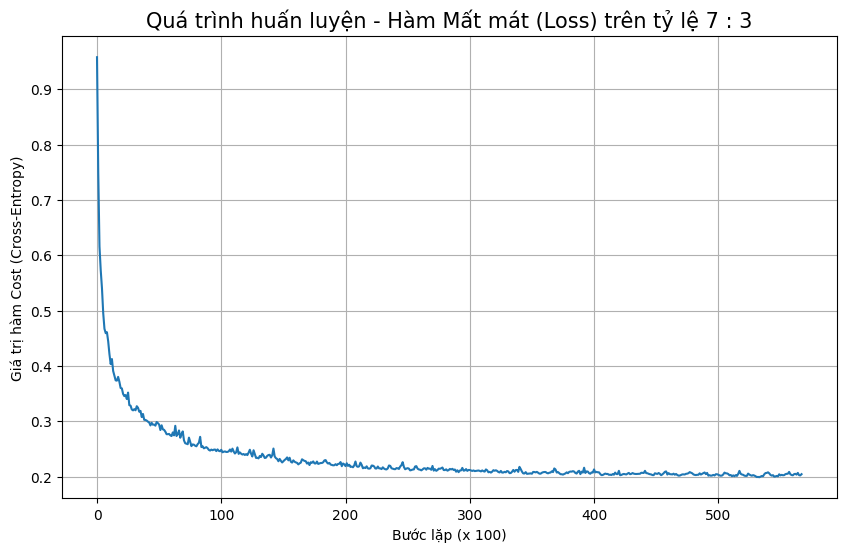

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Quá trình huấn luyện - Hàm Mất mát (Loss) trên tỷ lệ 7 : 3', fontsize=15)
plt.xlabel('Bước lặp (x 100)')
plt.ylabel('Giá trị hàm Cost (Cross-Entropy)')
plt.grid(True)
plt.show()

###### Dự đoán trên tập Train và Test

In [ ]:
train_scores = evaluate_model(y_train, y_pred_train)
test_scores = evaluate_model(y_test, y_pred_test)

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
print("Đánh giá mô hình:")
for i, m in enumerate(metrics):
    print(f"{m:10s}: Train = {train_scores[i]*100:.2f}% | Test = {test_scores[i]*100:.2f}%")


Đánh giá mô hình:
Accuracy  : Train = 91.35% | Test = 91.29%
Precision : Train = 91.45% | Test = 91.47%
Recall    : Train = 91.35% | Test = 91.29%
F1-score  : Train = 91.35% | Test = 91.30%


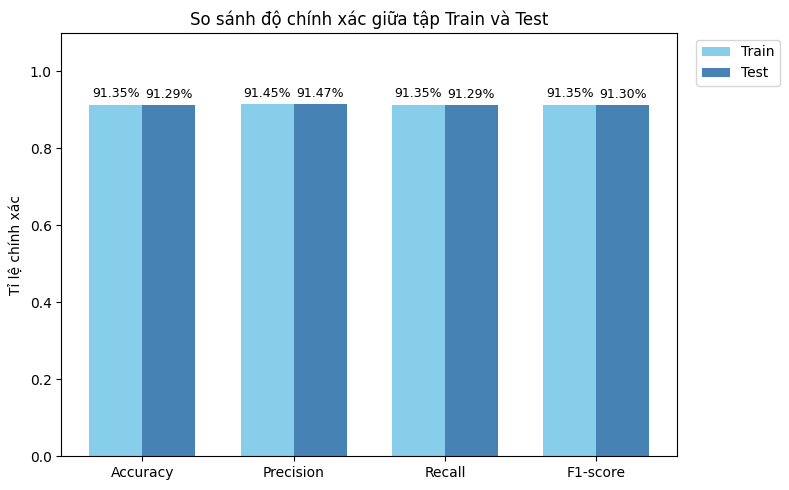

In [ ]:
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(8,5))
bar_train = plt.bar(x - width/2, train_scores, width, label='Train', color='#87CEEB')
bar_test = plt.bar(x + width/2, test_scores, width, label='Test', color='#4682B4')
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height*100:.2f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9)

add_labels(bar_train)
add_labels(bar_test)
plt.xticks(x, metrics)
plt.ylabel('Tỉ lệ chính xác')
plt.title('So sánh độ chính xác giữa tập Train và Test')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Trực quan hóa và đánh giá tương quan giữa phần dư

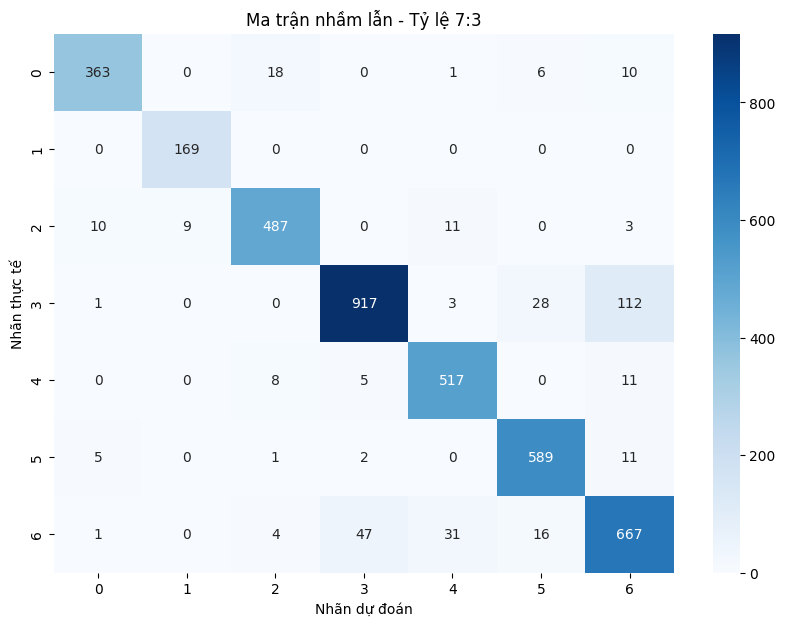

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực tế')
plt.title('Ma trận nhầm lẫn - Tỷ lệ 7:3')
plt.show()

## THEO PHƯƠNG PHÁP LDA

### ĐỌC DỮ LIỆU

In [ ]:
df = pd.read_excel("https://docs.google.com/spreadsheets/d/1gsKRl3Rl0yEuGBVCnBGjFnp7KH9tVG2l/export?format=xlsx")
df

,LD1,LD2,LD3,LD4,LD5,Class
0,-0.062268,-0.152487,0.041454,-0.190514,-0.098179,5
1,-0.034335,-0.100429,-0.036634,-0.173798,-0.039372,5
2,-0.066512,-0.143881,0.039807,-0.211773,-0.081166,5
3,-0.069313,-0.095768,0.002689,-0.177959,-0.065102,5
4,-0.013333,-0.152390,-0.042804,-0.171972,-0.147650,5
...,...,...,...,...,...,...
13538,-0.038437,-0.056703,-0.001900,0.068654,0.001024,3
13539,-0.037793,-0.066235,-0.017870,0.034369,-0.007916,3
13540,-0.038494,-0.063746,-0.012013,0.036466,-0.013743,3
13541,-0.037426,-0.053348,-0.010896,0.050559,-0.013832,3


### CHIA TẬP DỮ LIỆU

In [ ]:
np.random.seed(42)


#### Chia tỷ lệ 4 : 1

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
X_train_scaled, X_test_scaled = prepare_data(X_train, X_test)


In [ ]:
d = X_train_scaled.shape[0]
W_init = np.random.randn(d, C)
eta = .05
start_train = time.time()
# Ví dụ thay đổi dòng này:
W, losses = softmax_regression(X_train_scaled, y_train, W_init, eta, class_weights=class_weights_arr)
end_train = time.time()
train_time = end_train - start_train
y_pred_train = pred(W[-1], X_train_scaled)


start_test = time.time()
y_pred_test = pred(W[-1], X_test_scaled)
end_test = time.time()
predict_time = end_test - start_test




print("Thời gian huấn luyện trên dữ liệu LDA tỷ lệ (4 : 1) : ", train_time)
print("Thời gian dự đoán trên dữ liệu LDA tỷ lệ (4 : 1) : ", predict_time)

Thời gian huấn luyện trên dữ liệu LDA tỷ lệ (4 : 1) :  2.9732606410980225
Thời gian dự đoán trên dữ liệu LDA tỷ lệ (4 : 1) :  0.0011568069458007812


##### Biểu diễn hàm mất mất

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Quá trình huấn luyện - Hàm Mất mát (Loss) trên tỷ lệ 4 : 1', fontsize=15)
plt.xlabel('Bước lặp (x 100)')
plt.ylabel('Giá trị hàm Cost (Cross-Entropy)')
plt.grid(True)
plt.show()

##### Dự đoán trên tập Train và Test

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
print("Đánh giá mô hình:")
for i, m in enumerate(metrics):
    print(f"{m:10s}: Train = {train_scores[i]*100:.2f}% | Test = {test_scores[i]*100:.2f}%")


In [ ]:
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(8,5))
bar_train = plt.bar(x - width/2, train_scores, width, label='Train', color='#87CEEB')
bar_test = plt.bar(x + width/2, test_scores, width, label='Test', color='#4682B4')
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height*100:.2f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9)

add_labels(bar_train)
add_labels(bar_test)
plt.xticks(x, metrics)
plt.ylabel('Tỉ lệ chính xác')
plt.title('So sánh độ chính xác giữa tập Train và Test')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Trực quan hóa và đánh giá tương quan giữa phần dư

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực tế')
plt.title('Ma trận nhầm lẫn - Tỷ lệ 4:1')
plt.show()

#### Chia tỷ lệ 6 : 4

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)


In [ ]:
X_train_scaled, X_test_scaled = prepare_data(X_train, X_test)


In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
print("Đánh giá mô hình:")
for i, m in enumerate(metrics):
    print(f"{m:10s}: Train = {train_scores[i]*100:.2f}% | Test = {test_scores[i]*100:.2f}%")


In [ ]:
d = X_train_scaled.shape[0]
W_init = np.random.randn(d, C)
eta = .05
start_train = time.time()
# Ví dụ thay đổi dòng này:
W, losses = softmax_regression(X_train_scaled, y_train, W_init, eta, class_weights=class_weights_arr)
end_train = time.time()
train_time = end_train - start_train
y_pred_train = pred(W[-1], X_train_scaled)


start_test = time.time()
y_pred_test = pred(W[-1], X_test_scaled)
end_test = time.time()
predict_time = end_test - start_test



print("Thời gian huấn luyện trên dữ liệu LDA tỷ lệ (6 : 4) : ", train_time)
print("Thời gian dự đoán trên dữ liệu LDA tỷ lệ (6 : 4) : ", predict_time)

##### Biểu diễn hàm mất mát

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Quá trình huấn luyện - Hàm Mất mát (Loss) trên tỷ lệ 6 : 4', fontsize=15)
plt.xlabel('Bước lặp (x 100)')
plt.ylabel('Giá trị hàm Cost (Cross-Entropy)')
plt.grid(True)
plt.show()

##### Dự đoán trên tập Test và Train

In [ ]:
train_scores = evaluate_model(y_train, y_pred_train)
test_scores = evaluate_model(y_test, y_pred_test)

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
print("Đánh giá mô hình:")
for i, m in enumerate(metrics):
    print(f"{m:10s}: Train = {train_scores[i]*100:.2f}% | Test = {test_scores[i]*100:.2f}%")


In [ ]:
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(8,5))
bar_train = plt.bar(x - width/2, train_scores, width, label='Train', color='#87CEEB')
bar_test = plt.bar(x + width/2, test_scores, width, label='Test', color='#4682B4')
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height*100:.2f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9)

add_labels(bar_train)
add_labels(bar_test)
plt.xticks(x, metrics)
plt.ylabel('Tỉ lệ chính xác')
plt.title('So sánh độ chính xác giữa tập Train và Test')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Trực quan hóa và đánh giá tương quan giữa phần dư

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực tế')
plt.title('Ma trận nhầm lẫn - Tỷ lệ 6:4')
plt.show()

#### Chai tỷ lệ 7 : 3

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


In [ ]:
X_train_scaled, X_test_scaled = prepare_data(X_train, X_test)


In [ ]:
d = X_train_scaled.shape[0]
W_init = np.random.randn(d, C)
eta = .05
start_train = time.time()
# Ví dụ thay đổi dòng này:
W, losses = softmax_regression(X_train_scaled, y_train, W_init, eta, class_weights=class_weights_arr)
end_train = time.time()
train_time = end_train - start_train
y_pred_train = pred(W[-1], X_train_scaled)


start_test = time.time()
y_pred_test = pred(W[-1], X_test_scaled)
end_test = time.time()
predict_time = end_test - start_test





print("Thời gian huấn luyện trên dữ liệu LDA tỷ lệ (7 : 3) : ", train_time)
print("Thời gian dự đoán trên dữ liệu LDA tỷ lệ (7 : 3) : ", predict_time)

##### Biểu diễn hàm mất mát

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Quá trình huấn luyện - Hàm Mất mát (Loss) trên tỷ lệ 7 : 3', fontsize=15)
plt.xlabel('Bước lặp (x 1000)')
plt.ylabel('Giá trị hàm Cost (Cross-Entropy)')
plt.grid(True)
plt.show()

##### Dự đoán trên tập Train và Test

In [ ]:
train_scores = evaluate_model(y_train, y_pred_train)
test_scores = evaluate_model(y_test, y_pred_test)

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
print("Đánh giá mô hình:")
for i, m in enumerate(metrics):
    print(f"{m:10s}: Train = {train_scores[i]*100:.2f}% | Test = {test_scores[i]*100:.2f}%")


In [ ]:
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(8,5))
bar_train = plt.bar(x - width/2, train_scores, width, label='Train', color='#87CEEB')
bar_test = plt.bar(x + width/2, test_scores, width, label='Test', color='#4682B4')
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.annotate(f'{height*100:.2f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),
                     textcoords="offset points",
                     ha='center', va='bottom',
                     fontsize=9)

add_labels(bar_train)
add_labels(bar_test)
plt.xticks(x, metrics)
plt.ylabel('Tỉ lệ chính xác')
plt.title('So sánh độ chính xác giữa tập Train và Test')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Trực quan hóa và đánh giá tương quan giữa phần dư

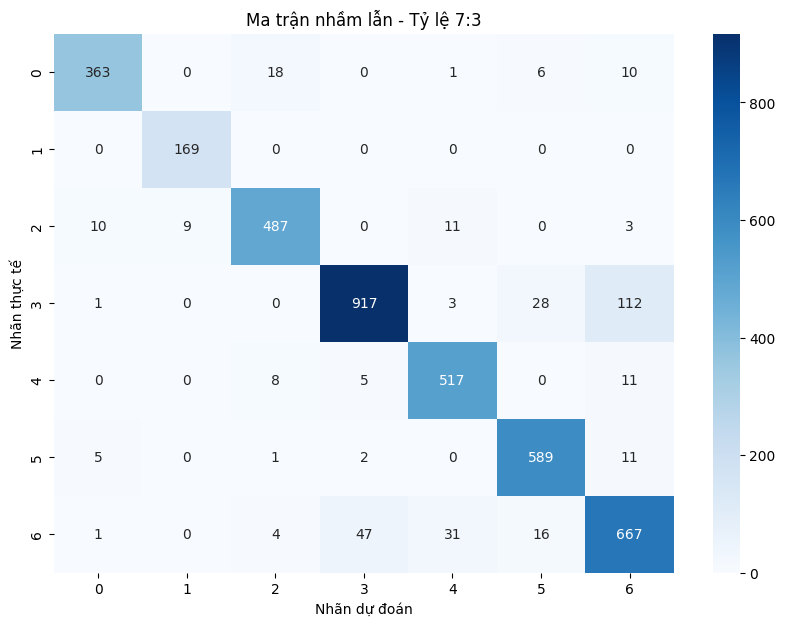

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực tế')
plt.title('Ma trận nhầm lẫn - Tỷ lệ 7:3')
plt.show()